In [22]:
import numpy as np
import scipy.linalg as sla
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import time
from pathlib import Path

from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [23]:

PASTA_IMAGENS = "/content/imagens"

TAMANHO_MAX = 64

TIPO_MASCARA = 'retangulo'

PORCENTAGEM_MASK = 0.20

EXTENSOES = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')


def listar_imagens(pasta):
    """Lista todos os arquivos de imagem na pasta informada."""
    pasta = Path(pasta)
    if not pasta.exists():
        print(f"[AVISO] Pasta '{pasta}' não encontrada.")
        print("Criando pasta de exemplo e gerando imagem sintética para demo...")
        pasta.mkdir(parents=True, exist_ok=True)
        _criar_imagem_demo(pasta)
    arquivos = sorted([f for f in pasta.iterdir() if f.suffix.lower() in EXTENSOES])
    print(f"Encontradas {len(arquivos)} imagem(ns) em '{pasta}'")
    for f in arquivos:
        print(f"  → {f.name}")
    return arquivos

def _criar_imagem_demo(pasta):
    """Cria uma imagem de teste caso nenhuma seja fornecida."""
    img = np.zeros((80, 80), dtype=np.uint8)
    # Gradiente suave
    for i in range(80):
        for j in range(80):
            img[i, j] = int(255 * (i + j) / 160)
    # Adiciona um círculo
    cx, cy, r = 40, 40, 20
    for i in range(80):
        for j in range(80):
            if (i - cx)**2 + (j - cy)**2 < r**2:
                img[i, j] = min(255, img[i, j] + 100)
    Image.fromarray(img).save(pasta / 'demo_sintetica.png')
    print("  → demo_sintetica.png criada.")

LISTA_IMAGENS = listar_imagens(PASTA_IMAGENS)

Encontradas 1 imagem(ns) em '/content/imagens'
  → img.png


## Célula 3 – Funções de Pré-processamento

In [24]:
def carregar_imagem(caminho, tamanho_max=64):
    """
    Carrega uma imagem, converte para escala de cinza e recorta
    um patch central de `tamanho_max x tamanho_max` pixels.
    Retorna array float64 normalizado em [0, 1].
    """
    img = Image.open(caminho).convert('L')  # escala de cinza
    w, h = img.size
    # Recorte central
    lado = min(w, h, tamanho_max)
    left  = (w - lado) // 2
    top   = (h - lado) // 2
    img   = img.crop((left, top, left + lado, top + lado))
    arr   = np.array(img, dtype=np.float64) / 255.0
    return arr


def gerar_mascara(shape, tipo='retangulo', frac=0.2, seed=42):
    """
    Gera uma máscara binária onde True = pixel desconhecido (a ser restaurado).

    Tipos disponíveis:
      'retangulo'       – retângulo central removido
      'pixels_aleatorios' – pixels aleatórios removidos
      'risco'           – faixa diagonal removida
    """
    rng  = np.random.default_rng(seed)
    mask = np.zeros(shape, dtype=bool)
    h, w = shape

    if tipo == 'retangulo':
        h0, h1 = h // 4, 3 * h // 4
        w0, w1 = w // 4, 3 * w // 4
        mask[h0:h1, w0:w1] = True

    elif tipo == 'pixels_aleatorios':
        n_pixels = int(frac * h * w)
        indices  = rng.choice(h * w, size=n_pixels, replace=False)
        mask.ravel()[indices] = True

    elif tipo == 'risco':
        espessura = max(2, h // 10)
        for k in range(min(h, w)):
            for d in range(-espessura, espessura + 1):
                if 0 <= k + d < h and 0 <= k < w:
                    mask[k + d, k] = True
    else:
        raise ValueError(f"Tipo de máscara desconhecido: {tipo}")

    return mask


def aplicar_mascara(img, mask):
    """Retorna imagem com pixels mascarados zerados (simulando dados ausentes)."""
    img_corrompida = img.copy()
    img_corrompida[mask] = 0.0
    return img_corrompida


print("Funções de pré-processamento definidas.")

Funções de pré-processamento definidas.


## Célula 4 – Montagem do Sistema Linear $Ax = b$ (Laplaciano Discreto)

Para cada pixel desconhecido $(i,j)$ na máscara, aplicamos a condição do Laplaciano discreto:

$$-4\,u(i,j) + u(i-1,j) + u(i+1,j) + u(i,j-1) + u(i,j+1) = 0$$

Se um vizinho for **conhecido**, ele vai para o lado direito $b$. Se for **desconhecido**, fica no lado esquerdo $A$.

In [5]:
def montar_sistema(img_corrompida, mask):
    """
    Constrói a matriz A e o vetor b para o sistema Ax = b
    usando o Laplaciano discreto sobre os pixels mascarados.

    Parâmetros
    ----------
    img_corrompida : ndarray (H, W)  – imagem com pixels ausentes zerados
    mask           : ndarray bool    – True onde o pixel é desconhecido

    Retorna
    -------
    A   : ndarray (N, N)  – matriz do sistema (N = número de pixels desconhecidos)
    b   : ndarray (N,)    – vetor de termos independentes
    idx : dict            – mapeia (i,j) -> índice na incógnita x
    """
    H, W = img_corrompida.shape

    pixels_mask = np.argwhere(mask)
    N = len(pixels_mask)
    idx = {(r, c): k for k, (r, c) in enumerate(pixels_mask)}

    A = np.zeros((N, N), dtype=np.float64)
    b = np.zeros(N,      dtype=np.float64)

    vizinhos = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for k, (r, c) in enumerate(pixels_mask):
        A[k, k] = -4.0
        for dr, dc in vizinhos:
            nr, nc = r + dr, c + dc

            if nr < 0 or nr >= H or nc < 0 or nc >= W:

                A[k, k] += 1.0
            elif mask[nr, nc]:
                j_viz = idx[(nr, nc)]
                A[k, j_viz] = 1.0
            else:
                b[k] -= img_corrompida[nr, nc]

    return A, b, idx, pixels_mask


print("Função de montagem do sistema definida.")

Função de montagem do sistema definida.


## Célula 5 – Implementação da Decomposição LU (Doolittle com Pivotamento Parcial)

Implementação **do zero** (sem usar `scipy.linalg.lu`), seguindo o algoritmo de Doolittle visto em aula.

A decomposição obtém $\mathbf{P}$, $\mathbf{L}$, $\mathbf{U}$ tais que $\mathbf{PA} = \mathbf{LU}$.

In [6]:
def lu_doolittle(A):
    """
    Decomposição LU com pivotamento parcial (método de Doolittle).
    Retorna P, L, U tais que P @ A = L @ U.

    Parâmetros
    ----------
    A : ndarray (n, n)

    Retorna
    -------
    P : ndarray (n, n) – matriz de permutação
    L : ndarray (n, n) – triangular inferior com diagonal = 1
    U : ndarray (n, n) – triangular superior
    """
    n = A.shape[0]
    U = A.astype(np.float64).copy()
    L = np.eye(n, dtype=np.float64)
    P = np.eye(n, dtype=np.float64)

    for k in range(n - 1):
        max_linha = k + np.argmax(np.abs(U[k:, k]))

        if max_linha != k:
            U[[k, max_linha], :] = U[[max_linha, k], :]
            P[[k, max_linha], :] = P[[max_linha, k], :]
            if k > 0:
                L[[k, max_linha], :k] = L[[max_linha, k], :k]

        if U[k, k] == 0:
            raise ValueError("Matriz singular detectada na decomposição LU.")

        for i in range(k + 1, n):
            fator = U[i, k] / U[k, k]
            L[i, k] = fator
            U[i, k:] -= fator * U[k, k:]

    return P, L, U


def substituicao_progressiva(L, b):
    """
    Resolve L @ y = b por substituição progressiva (forward substitution).
    L deve ser triangular inferior com diagonal = 1.
    """
    n = len(b)
    y = np.zeros(n, dtype=np.float64)
    for i in range(n):
        y[i] = b[i] - L[i, :i] @ y[:i]
    return y


def substituicao_regressiva(U, y):
    """
    Resolve U @ x = y por substituição regressiva (back substitution).
    U deve ser triangular superior.
    """
    n = len(y)
    x = np.zeros(n, dtype=np.float64)
    for i in range(n - 1, -1, -1):
        x[i] = (y[i] - U[i, i+1:] @ x[i+1:]) / U[i, i]
    return x


def resolver_lu_proprio(A, b):
    """
    Resolve Ax = b usando a decomposição LU implementada do zero.
    Fluxo:
      1. PA = LU  (decomposição)
      2. Ly = Pb  (substituição progressiva)
      3. Ux = y   (substituição regressiva)
    """
    P, L, U = lu_doolittle(A)
    Pb = P @ b
    y  = substituicao_progressiva(L, Pb)
    x  = substituicao_regressiva(U, y)
    return x, P, L, U


print("Decomposição LU e substituições implementadas do zero!")

Decomposição LU e substituições implementadas do zero!


## Célula 6 – Verificação da Implementação LU

Validação com o exemplo do material de aula:

In [7]:
A_teste = np.array([[1, 1,  1],
                    [2, 1, -1],
                    [2,-1,  1]], dtype=float)
b_teste = np.array([-2, 1, 3], dtype=float)

x_proprio, P, L, U = resolver_lu_proprio(A_teste, b_teste)
x_scipy  = sla.solve(A_teste, b_teste)

print("=== Verificação da implementação LU ===")
print(f"\nSolução (implementação própria): {x_proprio}")
print(f"Solução (scipy.linalg.solve):    {x_scipy}")
print(f"\nResíduo ||Ax - b|| (própria):  {np.linalg.norm(A_teste @ x_proprio - b_teste):.2e}")
print(f"Verificação PA = LU:            {np.allclose(P @ A_teste, L @ U)}")

print("\nMatriz L:")
print(np.round(L, 4))
print("\nMatriz U:")
print(np.round(U, 4))
print("\nMatriz P:")
print(P.astype(int))

=== Verificação da implementação LU ===

Solução (implementação própria): [ 1. -2. -1.]
Solução (scipy.linalg.solve):    [ 1. -2. -1.]

Resíduo ||Ax - b|| (própria):  0.00e+00
Verificação PA = LU:            True

Matriz L:
[[ 1.    0.    0.  ]
 [ 1.    1.    0.  ]
 [ 0.5  -0.25  1.  ]]

Matriz U:
[[ 2.  1. -1.]
 [ 0. -2.  2.]
 [ 0.  0.  2.]]

Matriz P:
[[0 1 0]
 [0 0 1]
 [1 0 0]]


## Célula 7 – Pipeline Completo de Inpainting

In [8]:
def reconstruir_imagem(img_corrompida, mask, x_solucao, pixels_mask):
    """
    Insere os valores encontrados pelo solver de volta na imagem.
    """
    img_rec = img_corrompida.copy()
    for k, (r, c) in enumerate(pixels_mask):
        img_rec[r, c] = np.clip(x_solucao[k], 0.0, 1.0)
    return img_rec


def inpainting_lu(caminho_imagem,
                  tamanho_max=TAMANHO_MAX,
                  tipo_mascara=TIPO_MASCARA,
                  frac=PORCENTAGEM_MASK,
                  usar_scipy=False,
                  verbose=True):
    """
    Pipeline completo:
      1. Carrega imagem
      2. Gera máscara
      3. Monta Ax = b
      4. Resolve via LU
      5. Reconstrói imagem
      6. Calcula métricas

    Retorna um dicionário com todos os resultados.
    """
    nome = Path(caminho_imagem).name

    img_original = carregar_imagem(caminho_imagem, tamanho_max)
    H, W = img_original.shape
    if verbose:
        print(f"[{nome}] Tamanho do patch: {H}x{W}  |  Pixels totais: {H*W}")

    mask = gerar_mascara((H, W), tipo=tipo_mascara, frac=frac)
    img_corrompida = aplicar_mascara(img_original, mask)
    n_desconhecidos = mask.sum()
    if verbose:
        print(f"[{nome}] Pixels desconhecidos (N): {n_desconhecidos}  "
              f"({100*n_desconhecidos/(H*W):.1f}% da imagem)")

    t0 = time.perf_counter()
    A, b, idx, pixels_mask = montar_sistema(img_corrompida, mask)
    t_montagem = time.perf_counter() - t0
    if verbose:
        print(f"[{nome}] Sistema Ax=b montado: A {A.shape}  |  tempo: {t_montagem:.3f}s")

    t0 = time.perf_counter()
    if usar_scipy:
        LU_fac, piv = sla.lu_factor(A)
        x = sla.lu_solve((LU_fac, piv), b)
        metodo = "scipy.linalg.lu_factor/lu_solve"
    else:
        x, _, _, _ = resolver_lu_proprio(A, b)
        metodo = "LU Doolittle (implementação própria)"
    t_solver = time.perf_counter() - t0
    if verbose:
        print(f"[{nome}] Solver: {metodo}  |  tempo: {t_solver:.3f}s")

    residuo = np.linalg.norm(A @ x - b)
    if verbose:
        print(f"[{nome}] Resíduo ||Ax - b||: {residuo:.2e}")

    img_restaurada = reconstruir_imagem(img_corrompida, mask, x, pixels_mask)


    psnr_val = psnr(img_original, img_restaurada, data_range=1.0)
    ssim_val = ssim(img_original, img_restaurada, data_range=1.0)
    if verbose:
        print(f"[{nome}] PSNR: {psnr_val:.2f} dB  |  SSIM: {ssim_val:.4f}")
        print("-" * 60)

    return {
        'nome'          : nome,
        'img_original'  : img_original,
        'img_corrompida': img_corrompida,
        'img_restaurada': img_restaurada,
        'mask'          : mask,
        'psnr'          : psnr_val,
        'ssim'          : ssim_val,
        'residuo'       : residuo,
        't_montagem'    : t_montagem,
        't_solver'      : t_solver,
        'N'             : n_desconhecidos,
        'metodo'        : metodo,
    }


print("Pipeline de inpainting pronto!")

Pipeline de inpainting pronto!


## Célula 8 – Funções de Visualização

In [9]:
def visualizar_resultado(resultado):
    """Exibe: imagem original | corrompida | restaurada + destaque da máscara."""
    r = resultado
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(f"{r['nome']}  |  PSNR={r['psnr']:.2f} dB  |  SSIM={r['ssim']:.4f}",
                 fontsize=13, fontweight='bold')

    axes[0].imshow(r['img_original'],   cmap='gray', vmin=0, vmax=1)
    axes[0].set_title('Original')

    axes[1].imshow(r['img_corrompida'], cmap='gray', vmin=0, vmax=1)
    axes[1].set_title('Corrompida (com máscara)')

    overlay = np.stack([r['img_corrompida']]*3, axis=-1)
    overlay[r['mask'], 0] = 1.0
    overlay[r['mask'], 1] = 0.0
    overlay[r['mask'], 2] = 0.0
    axes[2].imshow(overlay)
    axes[2].set_title('Máscara (vermelho = ausente)')

    axes[3].imshow(r['img_restaurada'], cmap='gray', vmin=0, vmax=1)
    axes[3].set_title('Restaurada (LU)')

    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


def visualizar_diferenca(resultado):
    """Exibe o mapa de erro absoluto entre original e restaurada."""
    r = resultado
    diff = np.abs(r['img_original'] - r['img_restaurada'])

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(f"Erro absoluto – {r['nome']}", fontsize=13)

    axes[0].imshow(r['img_restaurada'], cmap='gray', vmin=0, vmax=1)
    axes[0].set_title('Restaurada')

    im = axes[1].imshow(diff, cmap='hot', vmin=0, vmax=0.3)
    axes[1].set_title('Erro absoluto |original - restaurada|')
    plt.colorbar(im, ax=axes[1])

    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


def visualizar_matrizes_lu(A, tamanho_max_plot=30):
    """
    Visualiza as matrizes P, L, U da decomposição LU para sistemas pequenos.
    """
    N = A.shape[0]
    if N > tamanho_max_plot:
        print(f"Sistema grande (N={N}). Mostrando apenas bloco {tamanho_max_plot}x{tamanho_max_plot}.")
        A = A[:tamanho_max_plot, :tamanho_max_plot]

    P, L, U = lu_doolittle(A)

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle('Decomposição LU: PA = LU', fontsize=13, fontweight='bold')

    for ax, mat, titulo in zip(axes,
                                [A, P, L, U],
                                ['A (original)', 'P (permutação)', 'L (tri. inferior)', 'U (tri. superior)']):
        im = ax.imshow(mat, cmap='RdBu_r', aspect='auto')
        ax.set_title(titulo)
        plt.colorbar(im, ax=ax, shrink=0.8)

    plt.tight_layout()
    plt.show()


print("Funções de visualização definidas.")

Funções de visualização definidas.


## Célula 9 – Execução: Uma imagem (análise detalhada)

[img.png] Tamanho do patch: 64x64  |  Pixels totais: 4096
[img.png] Pixels desconhecidos (N): 1024  (25.0% da imagem)
[img.png] Sistema Ax=b montado: A (1024, 1024)  |  tempo: 0.048s
[img.png] Solver: LU Doolittle (implementação própria)  |  tempo: 3.986s
[img.png] Resíduo ||Ax - b||: 4.52e-15
[img.png] PSNR: 21.83 dB  |  SSIM: 0.8138
------------------------------------------------------------


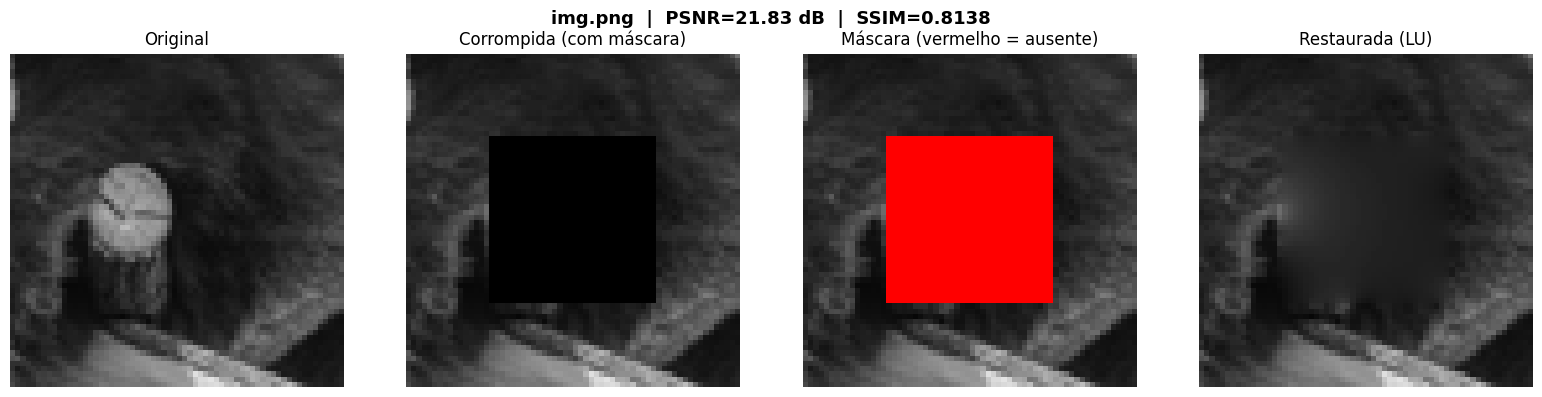

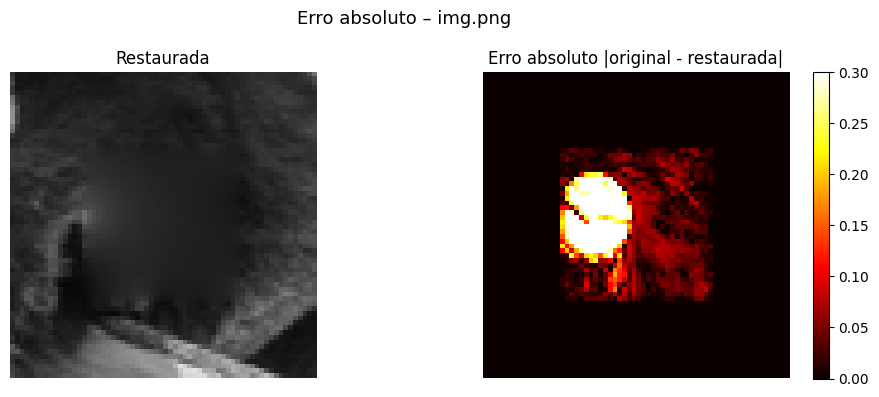

In [21]:
if len(LISTA_IMAGENS) == 0:
    print("Nenhuma imagem encontrada. Verifique PASTA_IMAGENS na Célula 2 ou faça upload de imagens.")
    print("Se você deseja usar uma imagem de demonstração, re-execute a Célula 2 para que ela possa ser criada e listada.")
else:
    image_path = LISTA_IMAGENS[0]
    if not Path(image_path).exists():
        print(f"ERRO: A imagem '{image_path}' não foi encontrada no disco, embora estivesse na LISTA_IMAGENS.")
        print("Isso pode ocorrer se os arquivos forem removidos do ambiente Colab.")
        print("Por favor, re-execute a Célula 2 (Configuração do Dataset) para garantir que as imagens estejam disponíveis.")
    else:
        resultado = inpainting_lu(
            image_path,
            tamanho_max   = TAMANHO_MAX,
            tipo_mascara  = TIPO_MASCARA,
            frac          = PORCENTAGEM_MASK,
            usar_scipy    = False,
            verbose       = True
        )

        visualizar_resultado(resultado)
        visualizar_diferenca(resultado)

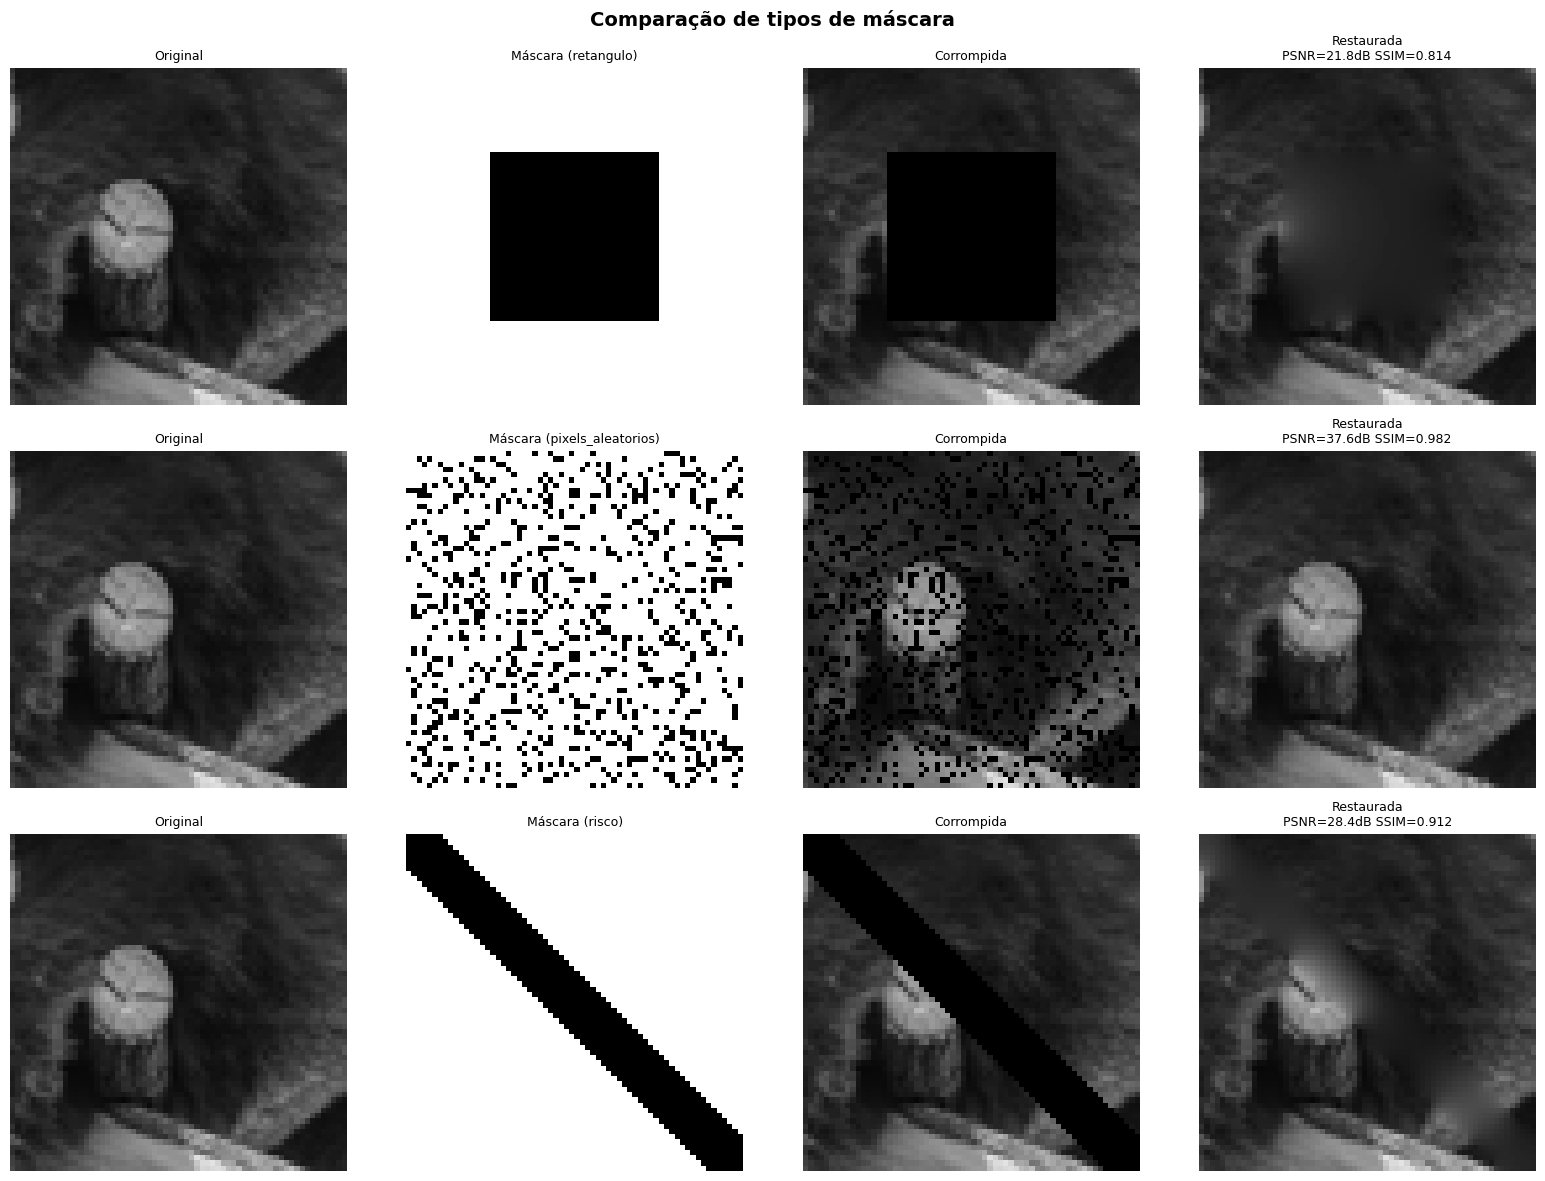

In [20]:
if len(LISTA_IMAGENS) > 0:
    tipos = ['retangulo', 'pixels_aleatorios', 'risco']
    fig, axes = plt.subplots(len(tipos), 4, figsize=(16, 4 * len(tipos)))
    fig.suptitle('Comparação de tipos de máscara', fontsize=14, fontweight='bold')

    for linha, tipo in enumerate(tipos):
        r = inpainting_lu(LISTA_IMAGENS[0],
                          tamanho_max  = TAMANHO_MAX,
                          tipo_mascara = tipo,
                          frac         = PORCENTAGEM_MASK,
                          usar_scipy   = False,
                          verbose      = False)

        titulos = ['Original', f'Máscara ({tipo})', 'Corrompida', f'Restaurada\nPSNR={r["psnr"]:.1f}dB SSIM={r["ssim"]:.3f}']
        imagens = [r['img_original'], r['mask'].astype(float), r['img_corrompida'], r['img_restaurada']]
        cmaps   = ['gray', 'binary', 'gray', 'gray']

        for col, (img, titulo, cmap) in enumerate(zip(imagens, titulos, cmaps)):
            ax = axes[linha][col] if len(tipos) > 1 else axes[col]
            ax.imshow(img, cmap=cmap, vmin=0, vmax=1)
            ax.set_title(titulo, fontsize=9)
            ax.axis('off')

    plt.tight_layout()
    plt.show()

## Célula 10 – Visualização das Matrizes L, U da Decomposição

Visualizando matrizes do sistema de tamanho (1024, 1024)
Sistema grande (N=1024). Mostrando apenas bloco 30x30.


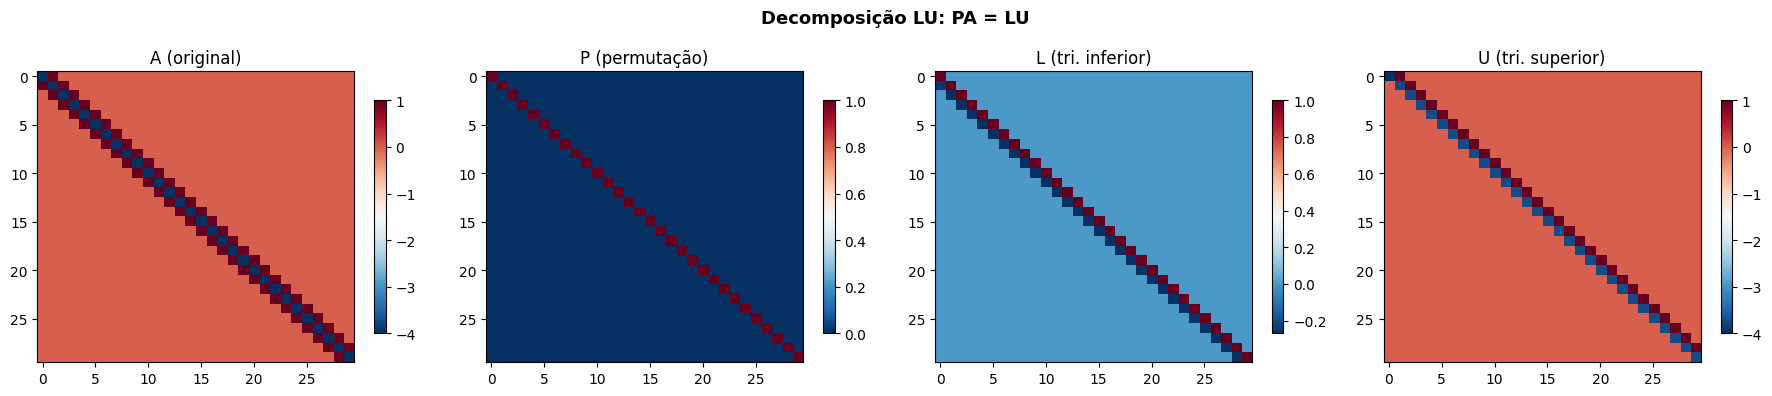

In [14]:
if len(LISTA_IMAGENS) > 0:
    # Monta novamente o sistema para visualizar as matrizes
    img_orig = carregar_imagem(LISTA_IMAGENS[0], tamanho_max=TAMANHO_MAX)
    mask_viz = gerar_mascara(img_orig.shape, tipo=TIPO_MASCARA, frac=PORCENTAGEM_MASK)
    img_corr = aplicar_mascara(img_orig, mask_viz)
    A_viz, b_viz, _, _ = montar_sistema(img_corr, mask_viz)
    print(f"Visualizando matrizes do sistema de tamanho {A_viz.shape}")
    visualizar_matrizes_lu(A_viz)

## Célula 11 – Processamento em Lote (Dataset Completo)

In [15]:
resultados_lote = []

for caminho in LISTA_IMAGENS:
    try:
        r = inpainting_lu(
            caminho,
            tamanho_max  = TAMANHO_MAX,
            tipo_mascara = TIPO_MASCARA,
            frac         = PORCENTAGEM_MASK,
            usar_scipy   = False,
            verbose      = True
        )
        resultados_lote.append(r)
    except Exception as e:
        print(f"[ERRO] {caminho.name}: {e}")

print(f"\nTotal processado: {len(resultados_lote)} imagem(ns)")

[img.png] Tamanho do patch: 64x64  |  Pixels totais: 4096
[img.png] Pixels desconhecidos (N): 1024  (25.0% da imagem)
[img.png] Sistema Ax=b montado: A (1024, 1024)  |  tempo: 0.011s
[img.png] Solver: LU Doolittle (implementação própria)  |  tempo: 2.482s
[img.png] Resíduo ||Ax - b||: 4.52e-15
[img.png] PSNR: 21.83 dB  |  SSIM: 0.8138
------------------------------------------------------------

Total processado: 1 imagem(ns)


## Célula 12 – Avaliação Quantitativa: PSNR, SSIM e Tempos

In [16]:
if resultados_lote:
    nomes    = [r['nome']       for r in resultados_lote]
    psnrs    = [r['psnr']       for r in resultados_lote]
    ssims    = [r['ssim']       for r in resultados_lote]
    tempos   = [r['t_solver']   for r in resultados_lote]
    Ns       = [r['N']          for r in resultados_lote]
    residuos = [r['residuo']    for r in resultados_lote]

    print("=" * 70)
    print(f"{'Imagem':<25} {'N':>6} {'PSNR (dB)':>10} {'SSIM':>8} {'Tempo (s)':>10} {'Resíduo':>12}")
    print("-" * 70)
    for i in range(len(resultados_lote)):
        print(f"{nomes[i]:<25} {Ns[i]:>6} {psnrs[i]:>10.2f} {ssims[i]:>8.4f} "
              f"{tempos[i]:>10.3f} {residuos[i]:>12.2e}")
    print("=" * 70)
    print(f"{'MÉDIA':<25} {np.mean(Ns):>6.0f} {np.mean(psnrs):>10.2f} {np.mean(ssims):>8.4f} "
          f"{np.mean(tempos):>10.3f}")

Imagem                         N  PSNR (dB)     SSIM  Tempo (s)      Resíduo
----------------------------------------------------------------------
img.png                     1024      21.83   0.8138      2.482     4.52e-15
MÉDIA                       1024      21.83   0.8138      2.482


## Célula 13 – Gráficos de Avaliação

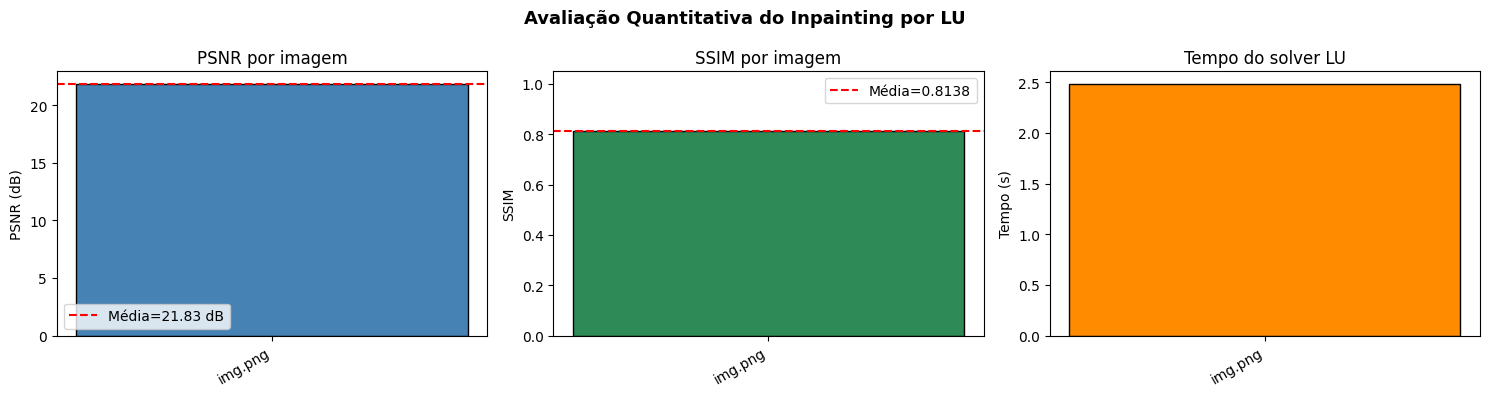

In [17]:
if resultados_lote:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Avaliação Quantitativa do Inpainting por LU', fontsize=13, fontweight='bold')

    x_pos = range(len(nomes))
    rotulos = [n[:15] for n in nomes]

    # PSNR
    axes[0].bar(x_pos, psnrs, color='steelblue', edgecolor='black')
    axes[0].axhline(np.mean(psnrs), color='red', linestyle='--', label=f'Média={np.mean(psnrs):.2f} dB')
    axes[0].set_xticks(x_pos); axes[0].set_xticklabels(rotulos, rotation=30, ha='right')
    axes[0].set_ylabel('PSNR (dB)'); axes[0].set_title('PSNR por imagem')
    axes[0].legend()

    # SSIM
    axes[1].bar(x_pos, ssims, color='seagreen', edgecolor='black')
    axes[1].axhline(np.mean(ssims), color='red', linestyle='--', label=f'Média={np.mean(ssims):.4f}')
    axes[1].set_xticks(x_pos); axes[1].set_xticklabels(rotulos, rotation=30, ha='right')
    axes[1].set_ylabel('SSIM'); axes[1].set_title('SSIM por imagem')
    axes[1].set_ylim(0, 1.05); axes[1].legend()

    # Tempo de solver
    axes[2].bar(x_pos, tempos, color='darkorange', edgecolor='black')
    axes[2].set_xticks(x_pos); axes[2].set_xticklabels(rotulos, rotation=30, ha='right')
    axes[2].set_ylabel('Tempo (s)'); axes[2].set_title('Tempo do solver LU')

    plt.tight_layout()
    plt.show()

## Célula 14 – Comparação: LU Próprio vs scipy

In [18]:
if len(LISTA_IMAGENS) > 0:
    print("Comparando implementação própria vs scipy...\n")

    r_proprio = inpainting_lu(LISTA_IMAGENS[0], usar_scipy=False, verbose=False)
    r_scipy   = inpainting_lu(LISTA_IMAGENS[0], usar_scipy=True,  verbose=False)

    print(f"{'Método':<40} {'PSNR':>8} {'SSIM':>8} {'Tempo (s)':>10}")
    print("-" * 70)
    print(f"{'LU Doolittle (próprio)':<40} {r_proprio['psnr']:>8.2f} {r_proprio['ssim']:>8.4f} "
          f"{r_proprio['t_solver']:>10.4f}")
    print(f"{'scipy.linalg.lu_factor/lu_solve':<40} {r_scipy['psnr']:>8.2f} {r_scipy['ssim']:>8.4f} "
          f"{r_scipy['t_solver']:>10.4f}")

    diff_max = np.max(np.abs(r_proprio['img_restaurada'] - r_scipy['img_restaurada']))
    print(f"\nDiferença máxima entre soluções: {diff_max:.2e}")

Comparando implementação própria vs scipy...

Método                                       PSNR     SSIM  Tempo (s)
----------------------------------------------------------------------
LU Doolittle (próprio)                      21.83   0.8138     2.8572
scipy.linalg.lu_factor/lu_solve             21.83   0.8138     0.0687

Diferença máxima entre soluções: 1.11e-15


## Célula 15 – Análise de Flops: Custo Computacional da Decomposição LU

Reproduz o quadro do material de aula comparando eliminação gaussiana com sistemas triangulares.

In [19]:
print("Análise de custo computacional (número de operações)")
print("=" * 65)
print(f"{'n':>6} | {'n³/3 (LU decomp.)':>20} | {'2n² (sist. triang.)':>20} | {'Redução':>8}")
print("-" * 65)
for n in [10, 100, 1000, 5000]:
    lu_ops  = n**3 / 3
    tri_ops = 2 * n**2
    reducao = (1 - tri_ops / lu_ops) * 100
    print(f"{n:>6} | {lu_ops:>20.2e} | {tri_ops:>20.2e} | {reducao:>7.1f}%")
print("=" * 65)
print("\nConclusion: para n grande, resolver sistemas triangulares é")
print("drasticamente mais barato que refazer a eliminação gaussiana.")
print("Por isso a Decomposição LU é preferida quando múltiplos b's são usados.")

Análise de custo computacional (número de operações)
     n |    n³/3 (LU decomp.) |  2n² (sist. triang.) |  Redução
-----------------------------------------------------------------
    10 |             3.33e+02 |             2.00e+02 |    40.0%
   100 |             3.33e+05 |             2.00e+04 |    94.0%
  1000 |             3.33e+08 |             2.00e+06 |    99.4%
  5000 |             4.17e+10 |             5.00e+07 |    99.9%

Conclusion: para n grande, resolver sistemas triangulares é
drasticamente mais barato que refazer a eliminação gaussiana.
Por isso a Decomposição LU é preferida quando múltiplos b's são usados.


---

## Resumo do Projeto

| Componente | Descrição |
|:---|:---|
| **Problema** | Restauração de imagens com pixels ausentes (*inpainting*) |
| **Modelo matemático** | Laplaciano discreto → sistema linear $Ax = b$ |
| **Método numérico** | Decomposição LU com pivotamento parcial (Doolittle) |
| **Implementação** | Do zero (Doolittle) + validação com `scipy.linalg` |
| **Métricas** | PSNR (dB), SSIM, resíduo $\|Ax - b\|$, tempo de execução |
| **Dataset** | Imagens lidas de pasta local ou Google Drive |

### Por que LU é eficiente aqui?

A decomposição LU é especialmente vantajosa neste contexto porque:
- A matriz $A$ (do Laplaciano) **não muda** se processarmos os 3 canais de cor (R, G, B) separadamente — basta fazer a decomposição **uma vez** e resolver 3 sistemas.
- Para sistemas triangulares, o custo cai de $\mathcal{O}(n^3/3)$ para $\mathcal{O}(n^2)$ — redução de até 99%+ para $n$ grande.

---
*Projeto gerado para a disciplina de Métodos Numéricos – IFPB Campus Campina Grande*